# Training the model

The first step is to get a trained model. In this notebook we are going to train a simple classifier on the MNIST dataset using PyTorch.

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

SEED = 42
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Data

We start by loading the MNIST dataset using `torchvision.datasets`. We will use the training set for training the model and the test set for evaluation.

In [2]:
from torchvision import datasets, transforms

train_transform = transforms.Compose([
    transforms.RandomAffine(degrees=(0,10), translate=(0.0, 0.1), scale=(0.7, 1.1), shear=(0,10)),
    transforms.ToTensor(),
    # transforms.Normalize((0.1307,), (0.3081,)),
    transforms.Lambda(lambda x: x + 0.05 * torch.randn_like(x))
])
test_transform = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=train_transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=test_transform)

In [3]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False, num_workers=2)

## Neural Network Model

We define a simple feedforward neural network with two hidden layers

In [4]:
from preimage_sampling.models import ConvAutoencoder


model = ConvAutoencoder().to(device)

# Print number of parameters for encoder, decoder and total
num_encoder_params = sum(p.numel() for p in model.encoder.parameters())
num_decoder_params = sum(p.numel() for p in model.decoder.parameters())
num_total_params = num_encoder_params + num_decoder_params
print(f'Number of parameters in encoder: {num_encoder_params//1000}K')
print(f'Number of parameters in decoder: {num_decoder_params//1000}K')
print(f'Total number of parameters: {num_total_params//1000}K')

Number of parameters in encoder: 95K
Number of parameters in decoder: 16K
Total number of parameters: 111K


## Training

In [5]:
num_epochs = 100
initial_lr = 5e-3
final_lr = 1e-6

criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=initial_lr, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=final_lr)

progress_bar = tqdm(range(num_epochs), desc='Training', unit='epoch')
train_losses, test_losses = [], []
for epoch in progress_bar:
    model.train()
    running_loss = 0.0
    for images, _ in train_loader:
        images = images.to(device)

        optimizer.zero_grad()
        _, outputs = model(images)
        loss = criterion(outputs, images)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    model.eval()
    test_loss = 0.0
    correct = 0
    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)
            _, outputs = model(images)
            loss = criterion(outputs, images)
            test_loss += loss.item() * images.size(0)
    epoch_test_loss = test_loss / len(test_loader.dataset)
    test_losses.append(epoch_test_loss)

    progress_bar.set_postfix({'Train Loss': epoch_loss, 'Test Loss': epoch_test_loss})
    scheduler.step()   
    

Training:   0%|          | 0/100 [00:00<?, ?epoch/s]

/home/gabrielepintus/.conda/envs/py13/lib/python3.13/multiprocessing/popen_fork.py:67: DeprecationWarning: This process (pid=161809) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


Final Training loss: 0.00799037010371685
Final Test loss: 0.0034097474766895176


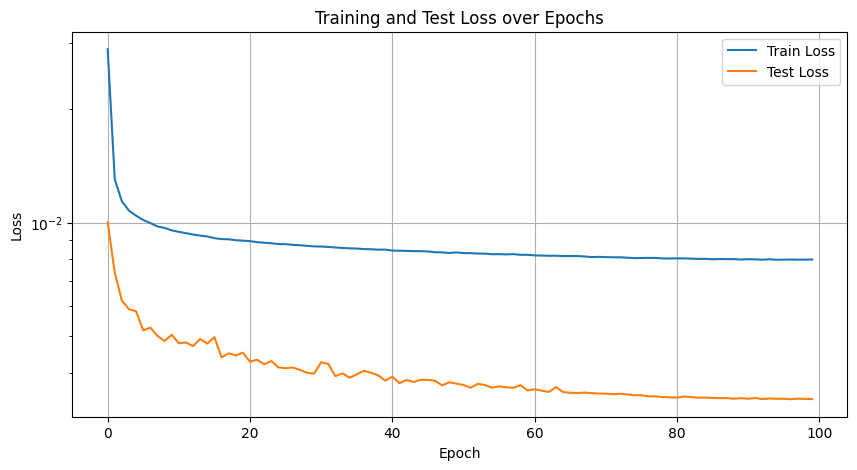

In [6]:
print("Final Training loss:", train_losses[-1])
print("Final Test loss:", test_losses[-1])

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.title('Training and Test Loss over Epochs')
plt.legend()
plt.grid()
plt.show()

## Visualizing latent space

In [7]:
# Encode the test set to visualize the latent space
model.eval()
latents, labels = [], []
with torch.no_grad():
    for images, targets in test_loader:
        images = images.to(device)
        latent, _ = model(images)
        latents.append(latent.cpu())
        labels.append(targets)
latents = torch.cat(latents)
labels = torch.cat(labels)

In [8]:
# Import TSNE and visualize the latent space
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=SEED)
latents_2d = tsne.fit_transform(latents.flatten(start_dim=1).numpy())

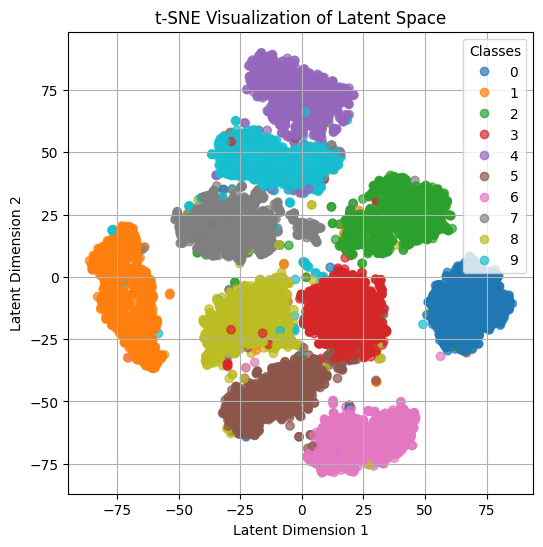

In [9]:
plt.figure(figsize=(6, 6))
scatter = plt.scatter(latents_2d[:, 0], latents_2d[:, 1], c=labels, cmap='tab10', alpha=0.7)
plt.legend(*scatter.legend_elements(), title="Classes")
plt.title('t-SNE Visualization of Latent Space')
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.grid()
plt.show()

## Visualizing reconstructions

/home/gabrielepintus/.conda/envs/py13/lib/python3.13/multiprocessing/popen_fork.py:67: DeprecationWarning: This process (pid=161809) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/home/gabrielepintus/.local/lib/python3.13/site-packages/matplotlib/cbook.py:684: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  x = np.array(x, subok=True, copy=copy)


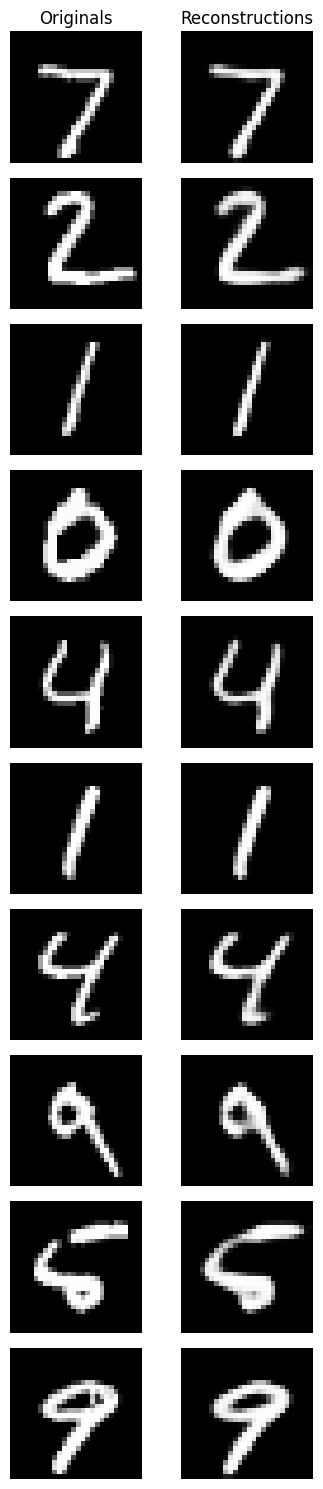

In [10]:
# Visualize reconstructions
model.eval()
with torch.no_grad():
    images, _ = next(iter(test_loader))
    images = images.to(device)
    _, outputs = model(images)
    outputs = outputs.cpu()
fig, axes = plt.subplots(10, 2, figsize=(4, 15))
for i in range(10):
    axes[i, 0].imshow(images[i].cpu().squeeze(), cmap='gray')
    axes[i, 0].axis('off')
    axes[i, 1].imshow(outputs[i].squeeze(), cmap='gray')
    axes[i, 1].axis('off')
axes[0, 0].set_title('Originals')
axes[0, 1].set_title('Reconstructions')
plt.tight_layout()
plt.show()

## Saving the Model

In [11]:
# Saving the model
torch.save(model.state_dict(), 'data/Trained Models/conv_ae.pth')